In [1]:
from pathlib import Path
import json
import os
import random
import shutil
import warnings

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, Image, display
from PIL import Image as PILImage, ImageDraw
from scipy.stats import kurtosis, skew
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

DATA_DIR = Path(r"Z:/Gophrt_AI")
OUT = DATA_DIR / "best_emotion_outputs"
FEATURE_SOURCE = DATA_DIR / "cnn_mel_outputs" / "feature_dataset.npz"
MODEL_DIR = OUT / "models"
REPORT_DIR = OUT / "reports"
SAMPLE_DIR = OUT / "sample_audio"
ALL_SAMPLE_DIR = OUT / "sample_audio_all_emotions"
for folder in [OUT, MODEL_DIR, REPORT_DIR, SAMPLE_DIR, ALL_SAMPLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SEED = 42
SAMPLE_RATE = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
FMIN = 50
FMAX = 8000
TOP_DB = 80

BANDS = {
    "band_1": (300, 627),
    "band_2": (628, 1060),
    "band_3": (1061, 1633),
    "band_4": (1634, 2393),
    "band_5": (2394, 3400),
}
EMOTIONS = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad", "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}

random.seed(SEED)
np.random.seed(SEED)
print("output:", OUT)

output: Z:\Gophrt_AI\best_emotion_outputs


In [9]:
def emotion_from_path(path):
    parts = Path(path).stem.split("-")
    return EMOTIONS.get(parts[2], "unknown") if len(parts) >= 3 else "unknown"


def audio_index():
    rows = []
    for path in sorted(DATA_DIR.glob("Actor_*/*.wav")):
        emotion = emotion_from_path(path)
        if emotion != "unknown":
            rows.append({"file": path.name, "path": str(path), "emotion": emotion, "actor": path.stem.split("-")[-1]})
    frame = pd.DataFrame(rows)
    frame.to_json(REPORT_DIR / "audio_index.json", orient="records", indent=2)
    return frame


def stat(values):
    values = np.asarray(values, dtype=np.float32).ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        return [0.0] * 14
    diffs = np.diff(values) if values.size > 1 else np.array([0.0], dtype=np.float32)
    return [
        float(np.mean(values)), float(np.std(values)), float(np.min(values)), float(np.max(values)),
        float(np.percentile(values, 5)), float(np.percentile(values, 10)), float(np.percentile(values, 25)),
        float(np.percentile(values, 50)), float(np.percentile(values, 75)), float(np.percentile(values, 90)),
        float(np.percentile(values, 95)), float(np.mean(np.abs(diffs))),
        float(skew(values, bias=False)) if values.size > 2 else 0.0,
        float(kurtosis(values, bias=False)) if values.size > 3 else 0.0,
    ]


def band_features(y, sr):
    spectrum = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    features = []
    total_energy = spectrum.sum(axis=0) + 1e-10
    for _, (low, high) in BANDS.items():
        mask = (freqs >= low) & (freqs <= high)
        band = spectrum[mask]
        band_freqs = freqs[mask]
        energy = band.sum(axis=0) + 1e-10
        centroid = (band_freqs[:, None] * band).sum(axis=0) / energy
        bandwidth = np.sqrt((((band_freqs[:, None] - centroid[None, :]) ** 2) * band).sum(axis=0) / energy)
        ratio = energy / total_energy
        features += stat(np.log1p(energy)) + stat(centroid) + stat(bandwidth) + stat(ratio)
    return features


def extract_features(audio_path, seconds=None, return_mel=False):
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True, duration=seconds)
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size < HOP_LENGTH:
        y = np.pad(y, (0, HOP_LENGTH - y.size))
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=TOP_DB).astype(np.float32)
    mfcc = librosa.feature.mfcc(S=mel_db, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    pitch = librosa.yin(y, fmin=50, fmax=500, sr=sr, frame_length=N_FFT, hop_length=HOP_LENGTH)
    features = [float(len(y) / sr), float(np.mean(np.abs(y))), float(np.std(y)), float(np.max(np.abs(y)))]
    for item in [mel_db, mel_db.mean(axis=0), mel_db.mean(axis=1), mfcc, delta, delta2, chroma, contrast, rms, zcr, centroid, bandwidth, rolloff, flatness, pitch]:
        features += stat(item)
    for chunk in np.array_split(mel_db, 8, axis=0):
        features += stat(chunk) + stat(chunk.mean(axis=0))
    features += band_features(y, sr)
    vector = np.nan_to_num(np.array(features, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    return (vector, mel_db) if return_mel else vector


def save_mel_image(mel_db, path):
    normalized = (np.clip(mel_db, -TOP_DB, 0) + TOP_DB) / TOP_DB
    rgb = (plt.get_cmap("magma")(normalized)[:, :, :3] * 255).astype(np.uint8)
    image = PILImage.fromarray(rgb)
    image = image.resize((image.width * 2, image.height * 2), PILImage.Resampling.NEAREST)
    image.save(path)

def augment_audio(y, sr, augmentation_type, rng):
    """
    Apply one audio augmentation.
    """

    y = y.astype(np.float32)

    if augmentation_type == "noise":
        # Add low-level Gaussian noise
        noise_level = 0.005 * (np.std(y) + 1e-8)
        noise = rng.normal(0, noise_level, size=len(y))
        augmented = y + noise.astype(np.float32)

    elif augmentation_type == "pitch":
        # Random pitch shift between -2 and +2 semitones
        n_steps = rng.uniform(-2.0, 2.0)

        augmented = librosa.effects.pitch_shift(
            y,
            sr=sr,
            n_steps=n_steps
        )

    elif augmentation_type == "stretch":
        # Slightly speed up or slow down
        rate = rng.uniform(0.9, 1.1)

        augmented = librosa.effects.time_stretch(                     ##TEST AUGMENTATION
            y,
            rate=rate
        )

    elif augmentation_type == "gain":
        # Slight volume change
        gain = rng.uniform(0.8, 1.2)
        augmented = y * gain

    else:
        augmented = y.copy()

    # Keep audio within valid range
    augmented = np.clip(augmented, -1.0, 1.0)

    return augmented.astype(np.float32)


AUGMENTATIONS = [
    "noise",
    "pitch",
    "stretch",
    "gain"
]

validation accuracy: 79.63%
test accuracy: 74.54%


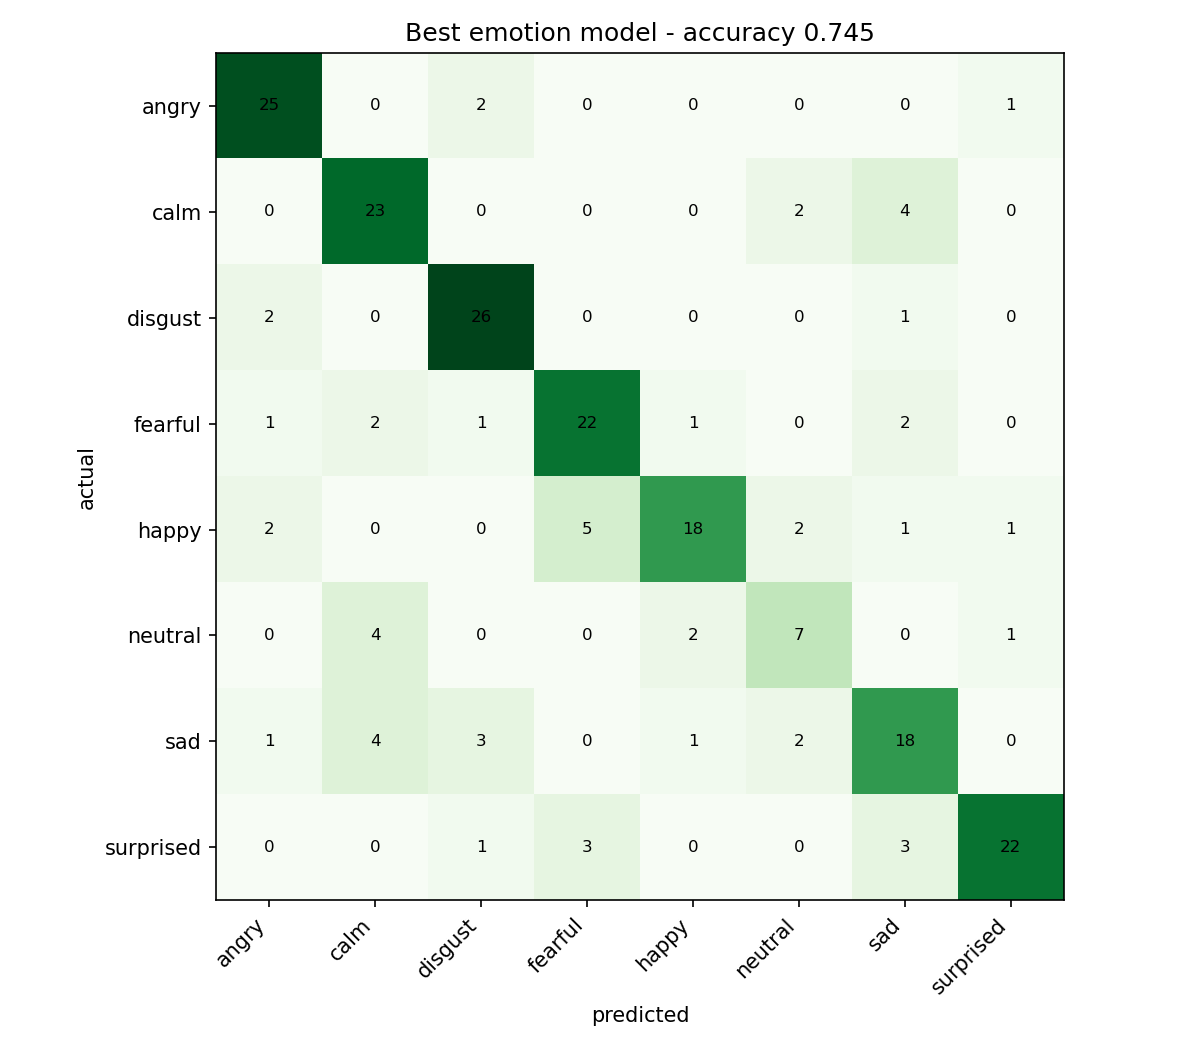

In [3]:
index = audio_index()
features = np.load(FEATURE_SOURCE, allow_pickle=True)
X = features["X"].astype(np.float32)
y = features["y"]
idx = np.arange(len(y))
train_val_idx, test_idx = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.15 / 0.85, random_state=SEED, stratify=y[train_val_idx])

quick_model = Pipeline([("scale", StandardScaler()), ("model", SVC(C=10, gamma=0.001, class_weight="balanced", random_state=SEED))])
quick_model.fit(X[train_idx], y[train_idx])
val_pred = quick_model.predict(X[val_idx])
val_accuracy = float(accuracy_score(y[val_idx], val_pred))

model = Pipeline([("scale", StandardScaler()), ("model", SVC(C=10, gamma=0.001, class_weight="balanced", random_state=SEED))])
model.fit(X[train_val_idx], y[train_val_idx])
test_pred = model.predict(X[test_idx])
test_accuracy = float(accuracy_score(y[test_idx], test_pred))
classes = sorted(np.unique(y).tolist())

cm = confusion_matrix(y[test_idx], test_pred, labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"Best emotion model - accuracy {test_accuracy:.3f}")
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        ax.text(c, r, int(cm[r, c]), ha="center", va="center", fontsize=8)
fig.tight_layout()
confusion_path = REPORT_DIR / "best_confusion_matrix.png"
fig.savefig(confusion_path, dpi=150)
plt.close(fig)

package = {"model": model, "classes": classes, "accuracy": test_accuracy, "feature_count": int(X.shape[1]), "settings": {"model": "RBF-SVC", "C": 10, "gamma": 0.001}}
model_path = MODEL_DIR / "best_emotion_model.joblib"
joblib.dump(package, model_path)
summary = {"validation_accuracy": val_accuracy, "test_accuracy": test_accuracy, "test_size": int(len(test_idx)), "feature_shape": list(X.shape), "model_path": str(model_path), "confusion_matrix": str(confusion_path), "classification_report": classification_report(y[test_idx], test_pred, labels=classes, output_dict=True, zero_division=0)}
with (REPORT_DIR / "best_quick_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print("validation accuracy:", f"{val_accuracy * 100:.2f}%")
print("test accuracy:", f"{test_accuracy * 100:.2f}%")
display(Image(filename=str(confusion_path)))

overall test accuracy: 74.54%


,emotion,samples,correct,accuracy
0,angry,28,25,0.892857
1,calm,29,23,0.793103
2,disgust,29,26,0.896552
3,fearful,29,22,0.758621
4,happy,29,18,0.620690
5,neutral,14,7,0.500000
6,sad,29,18,0.620690
7,surprised,29,22,0.758621


,emotion,file,predicted,correct,confidence_score
0,angry,03-01-05-01-02-01-08.wav,angry,True,0.803726
1,calm,03-01-02-02-01-02-22.wav,calm,True,0.668036
2,disgust,03-01-07-02-02-02-01.wav,disgust,True,0.723877
3,fearful,03-01-06-01-01-01-02.wav,fearful,True,0.768992
4,happy,03-01-03-01-01-02-13.wav,happy,True,0.787560
5,neutral,03-01-01-01-02-02-16.wav,neutral,True,0.750570
6,sad,03-01-04-02-01-01-20.wav,sad,True,0.742334
7,surprised,03-01-08-01-02-01-05.wav,surprised,True,0.747564


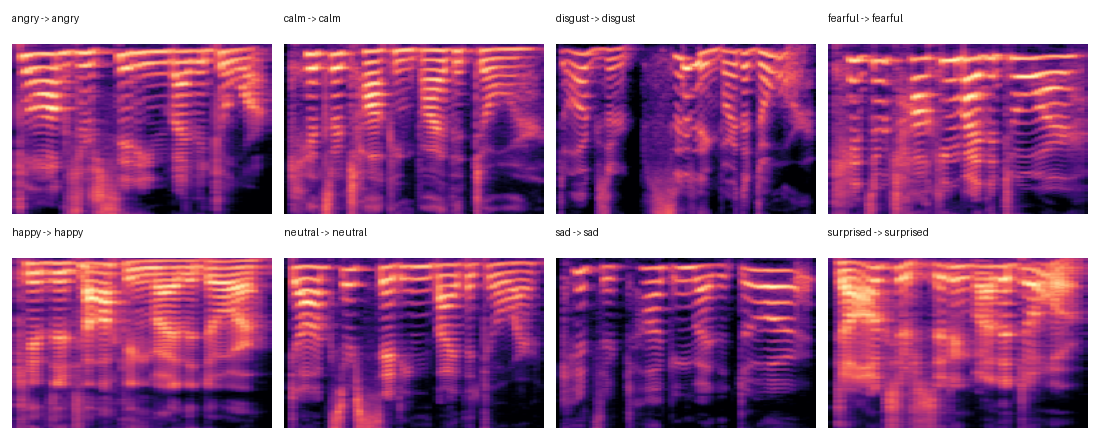

In [4]:
test_rows = []
scores = model.decision_function(X[test_idx])
scores = scores - scores.max(axis=1, keepdims=True)
confidence = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
for n, original_idx in enumerate(test_idx):
    row = index.iloc[int(original_idx)].to_dict()
    row["predicted"] = str(test_pred[n])
    row["correct"] = bool(test_pred[n] == y[original_idx])
    row["confidence_score"] = float(confidence[n].max())
    test_rows.append(row)

test_results = pd.DataFrame(test_rows)
per_emotion = test_results.groupby("emotion").agg(samples=("file", "count"), correct=("correct", "sum"), accuracy=("correct", "mean")).reset_index().sort_values("emotion")
sample_rows = []
for emotion in sorted(test_results["emotion"].unique()):
    subset = test_results[test_results["emotion"] == emotion]
    correct = subset[subset["correct"]]
    chosen = correct.sort_values("confidence_score", ascending=False).iloc[0] if len(correct) else subset.iloc[0]
    src = Path(chosen["path"])
    dst = ALL_SAMPLE_DIR / f"{emotion}_{src.name}"
    shutil.copy2(src, dst)
    row = chosen.to_dict()
    row["copied_sample"] = str(dst)
    _, mel_db = extract_features(src, seconds=15, return_mel=True)
    mel_path = REPORT_DIR / f"sample_{emotion}_mel.png"
    save_mel_image(mel_db, mel_path)
    row["mel_image"] = str(mel_path)
    sample_rows.append(row)

sample_table = pd.DataFrame(sample_rows)
test_results.to_csv(REPORT_DIR / "all_test_predictions.csv", index=False)
per_emotion.to_csv(REPORT_DIR / "per_emotion_accuracy.csv", index=False)
sample_table.to_csv(REPORT_DIR / "sample_predictions_all_emotions.csv", index=False)

thumb_w, thumb_h, label_h, margin, columns = 260, 170, 32, 12, 4
grid = PILImage.new("RGB", (margin + columns * (thumb_w + margin), margin + 2 * (thumb_h + label_h + margin)), "white")
draw = ImageDraw.Draw(grid)
for i, row in sample_table.reset_index(drop=True).iterrows():
    x0 = margin + (i % columns) * (thumb_w + margin)
    y0 = margin + (i // columns) * (thumb_h + label_h + margin)
    label = f"{row['emotion']} -> {row['predicted']}"
    draw.text((x0, y0), label, fill=(20, 20, 20))
    img = PILImage.open(row["mel_image"]).convert("RGB").resize((thumb_w, thumb_h), PILImage.Resampling.BILINEAR)
    grid.paste(img, (x0, y0 + label_h))
grid_path = REPORT_DIR / "all_emotion_sample_mel_grid.png"
grid.save(grid_path)

with (REPORT_DIR / "all_emotion_sample_summary.json").open("w", encoding="utf-8") as f:
    json.dump({
        "overall_test_accuracy": test_accuracy,
        "test_size": int(len(test_idx)),
        "per_emotion": per_emotion.to_dict(orient="records"),
        "sample_predictions": sample_table[["emotion", "file", "predicted", "correct", "confidence_score", "copied_sample"]].to_dict(orient="records"),
    }, f, indent=2)

print("overall test accuracy:", f"{test_accuracy * 100:.2f}%")
display(per_emotion)
display(sample_table[["emotion", "file", "predicted", "correct", "confidence_score"]])
display(Image(filename=str(grid_path)))
sample_copy = Path(sample_table.iloc[0]["copied_sample"])

audio: angry_03-01-05-01-02-01-08.wav
predicted emotion: angry


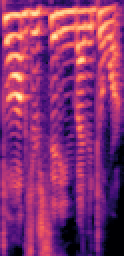

,emotion,confidence_score
0,angry,0.803726
1,surprised,0.093800
2,sad,0.032881
3,fearful,0.031653
4,happy,0.030090
5,neutral,0.004175
6,disgust,0.003262
7,calm,0.000413


In [5]:
def predict_emotion(audio_path, seconds=15, model_path=MODEL_DIR / "best_emotion_model.joblib"):
    package = joblib.load(model_path)
    model = package["model"]
    vector, mel_db = extract_features(audio_path, seconds=seconds, return_mel=True)
    predicted = model.predict(vector.reshape(1, -1))[0]
    scores = model.decision_function(vector.reshape(1, -1))[0]
    scores = scores - np.max(scores)
    confidence = np.exp(scores) / np.sum(np.exp(scores))
    result = pd.DataFrame({"emotion": model.classes_, "confidence_score": confidence}).sort_values("confidence_score", ascending=False).reset_index(drop=True)
    preview_path = REPORT_DIR / "latest_prediction_mel.png"
    save_mel_image(mel_db, preview_path)
    print("audio:", Path(audio_path).name)
    print("predicted emotion:", predicted)
    display(Audio(filename=str(audio_path)))
    display(Image(filename=str(preview_path)))
    return result

predict_emotion(sample_copy, seconds=15)

recording 5 seconds from: Headset (USB Audio)
saved: Z:\Gophrt_AI\best_emotion_outputs\microphone_recordings\mic_recording_20260907_182425.wav
peak level: 0.9977


audio: mic_recording_20260907_182425.wav
predicted emotion: fearful


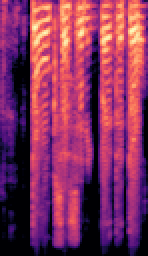

,emotion,confidence_score
0,fearful,0.645827
1,sad,0.226905
2,angry,0.081932
3,happy,0.030374
4,surprised,0.010750
5,disgust,0.002905
6,neutral,0.000960
7,calm,0.000347


In [8]:
import sounddevice as sd
import soundfile as sf
from datetime import datetime

MIC_DIR = OUT / "microphone_recordings"
MIC_DIR.mkdir(parents=True, exist_ok=True)


def record_microphone(seconds=5, device=None, normalize=True):
    input_info = sd.query_devices(device, "input") if device is not None else sd.query_devices(kind="input")
    record_sr = int(input_info["default_samplerate"])
    print(f"recording {seconds} seconds from: {input_info['name']}")
    audio = sd.rec(int(seconds * record_sr), samplerate=record_sr, channels=1, dtype="float32", device=device)
    sd.wait()
    peak = float(np.max(np.abs(audio))) if audio.size else 0.0
    if normalize and peak > 1e-5:
        audio = audio / peak * 0.90
    filename = MIC_DIR / f"mic_recording_{datetime.now().strftime('%Y%m%d_%H%M%S')}.wav"
    sf.write(filename, audio, record_sr)
    print("saved:", filename)
    print("peak level:", round(peak, 4))
    display(Audio(filename=str(filename)))
    return filename

mic_audio = record_microphone(seconds=5)
predict_emotion(mic_audio, seconds=15)